# Ejercicio 4: El Impacto de la Métrica

Comparación de A* usando distancia Manhattan y distancia Euclidiana

In [ ]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import time
import math
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
plt.ioff()

## 1. Funciones auxiliares y algoritmo A*

In [2]:
def obtenerVecinos(nodo, mapa):
    #4 direcciones cardinales
    filas, columnas = mapa.shape
    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    vecinos = []
    for df, dc in direcciones:
        nf, nc = nodo[0] + df, nodo[1] + dc
        if 0 <= nf < filas and 0 <= nc < columnas and mapa[nf][nc] == 0:
            vecinos.append((nf, nc))
    return vecinos

def heuristicaManhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def heuristicaEuclidiana(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def ejecutarAEstrella(mapa, inicio, fin, heuristica, nombreHeuristica):
    tiempoInicio = time.perf_counter()
    
    frontera = []
    contador = 0
    heapq.heappush(frontera, (0, contador, inicio))
    costoAcumulado = {inicio: 0}
    padres = {inicio: None}
    explorados = set()
    ordenExploracion = []
    pasos = 0
    
    while frontera:
        pasos += 1
        _, _, actual = heapq.heappop(frontera)
        
        if actual in explorados:
            continue
        
        explorados.add(actual)
        ordenExploracion.append(actual)
        
        if actual == fin:
            break
        
        for vecino in obtenerVecinos(actual, mapa):
            nuevoCosto = costoAcumulado[actual] + 1
            if vecino not in costoAcumulado or nuevoCosto < costoAcumulado[vecino]:
                costoAcumulado[vecino] = nuevoCosto
                prioridad = nuevoCosto + heuristica(vecino, fin)
                contador += 1
                heapq.heappush(frontera, (prioridad, contador, vecino))
                padres[vecino] = actual
    
    tiempoFin = time.perf_counter()
    
    camino = []
    nodo = fin
    while nodo is not None:
        camino.append(nodo)
        nodo = padres.get(nodo)
    camino.reverse()
    
    nodosFrontera = len([n for _, _, n in frontera if n not in explorados])
    
    return {
        'nombre': nombreHeuristica,
        'explorados': explorados,
        'ordenExploracion': ordenExploracion,
        'camino': camino,
        'numExplorados': len(explorados),
        'numFrontera': nodosFrontera,
        'pasos': pasos,
        'tiempo': tiempoFin - tiempoInicio,
        'distancia': len(camino) - 1
    }

print("Funciones definidas.")

Funciones definidas.


## 2. Generación de mapas y funciones

In [3]:
def generarMapa(filas, columnas, porcentajeObs, semilla, inicio, fin):
    np.random.seed(semilla)
    mapa = np.zeros((filas, columnas), dtype=int)
    for f in range(filas):
        for c in range(columnas):
            if np.random.random() < porcentajeObs:
                mapa[f][c] = 1
    for punto in [inicio, fin]:
        for df in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                nf, nc = punto[0]+df, punto[1]+dc
                if 0 <= nf < filas and 0 <= nc < columnas:
                    mapa[nf][nc] = 0
    return mapa

def dibujarMapa(ax, mapa, resultado, inicio, fin, colorBase, titulo):
    filas, columnas = mapa.shape
    imagen = np.ones((filas, columnas, 3))
    imagen[:, :] = [0.96, 0.96, 0.98]
    
    #obstaculos
    for f in range(filas):
        for c in range(columnas):
            if mapa[f][c] == 1:
                imagen[f][c] = [0.25, 0.25, 0.30]
    
    #nodos explorados con gradiente
    total = len(resultado['ordenExploracion'])
    for i, (f, c) in enumerate(resultado['ordenExploracion']):
        t = i / max(total - 1, 1)
        r = colorBase[0] - 0.30 * t
        g = colorBase[1] - 0.30 * t
        b = colorBase[2] - 0.15 * t
        imagen[f][c] = [max(r, 0.1), max(g, 0.1), max(b, 0.2)]
    
    #camino
    for f, c in resultado['camino']:
        imagen[f][c] = [1.0, 0.55, 0.10]
    
    imagen[inicio[0]][inicio[1]] = [0.18, 0.80, 0.44]
    imagen[fin[0]][fin[1]] = [0.91, 0.20, 0.25]
    
    ax.imshow(imagen, interpolation='nearest')
    ax.set_xticks(np.arange(-0.5, columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which='minor', color='#cccccc', linewidth=0.3)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titulo, fontsize=12, fontweight='bold', color='#2c3e50', pad=10)

print("Funciones de mapa y dibujo listas.")

Funciones de mapa y dibujo listas.


## 3. Experimento 1: Mapa 30×30 con  aprox 20% de obstáculos

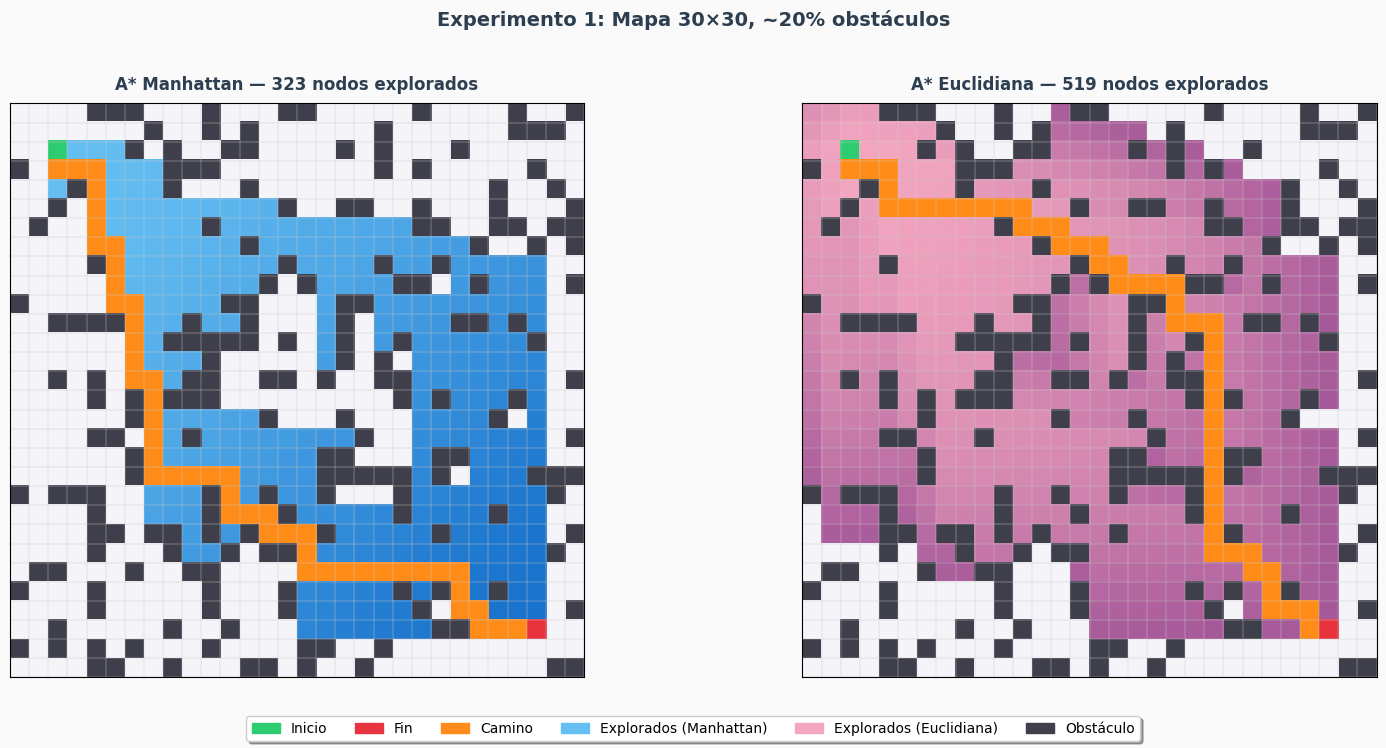


Imagen 1. Experimento 1 — Comparación de nodos explorados con Manhattan y Euclidiana (30×30)


In [4]:
inicio1 = (2, 2)
fin1 = (27, 27)
mapa1 = generarMapa(30, 30, 0.20, semilla=42, inicio=inicio1, fin=fin1)

resManhattan1 = ejecutarAEstrella(mapa1, inicio1, fin1, heuristicaManhattan, 'A* Manhattan')
resEuclidiana1 = ejecutarAEstrella(mapa1, inicio1, fin1, heuristicaEuclidiana, 'A* Euclidiana')

colorManhattan = [0.40, 0.75, 0.95]
colorEuclidiana = [0.95, 0.65, 0.75]

fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#fafafa')

dibujarMapa(ejes[0], mapa1, resManhattan1, inicio1, fin1, colorManhattan,
            f"A* Manhattan — {resManhattan1['numExplorados']} nodos explorados")
dibujarMapa(ejes[1], mapa1, resEuclidiana1, inicio1, fin1, colorEuclidiana,
            f"A* Euclidiana — {resEuclidiana1['numExplorados']} nodos explorados")

leyendas = [
    mpatches.Patch(color=[0.18, 0.80, 0.44], label='Inicio'),
    mpatches.Patch(color=[0.91, 0.20, 0.25], label='Fin'),
    mpatches.Patch(color=[1.0, 0.55, 0.10], label='Camino'),
    mpatches.Patch(color=colorManhattan, label='Explorados (Manhattan)'),
    mpatches.Patch(color=colorEuclidiana, label='Explorados (Euclidiana)'),
    mpatches.Patch(color=[0.25, 0.25, 0.30], label='Obstáculo'),
]
fig.legend(handles=leyendas, loc='lower center', ncol=6, fontsize=10,
           frameon=True, fancybox=True, shadow=True, edgecolor='#cccccc')

plt.suptitle('Experimento 1: Mapa 30×30, ~20% obstáculos', fontsize=14,
             fontweight='bold', color='#2c3e50')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig('exp1_comparacion.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 1. Experimento 1 — Comparación de nodos explorados con Manhattan y Euclidiana (30×30)")

## 4. Experimento 2: Mapa 40×40 con aprox 15% de obstáculos

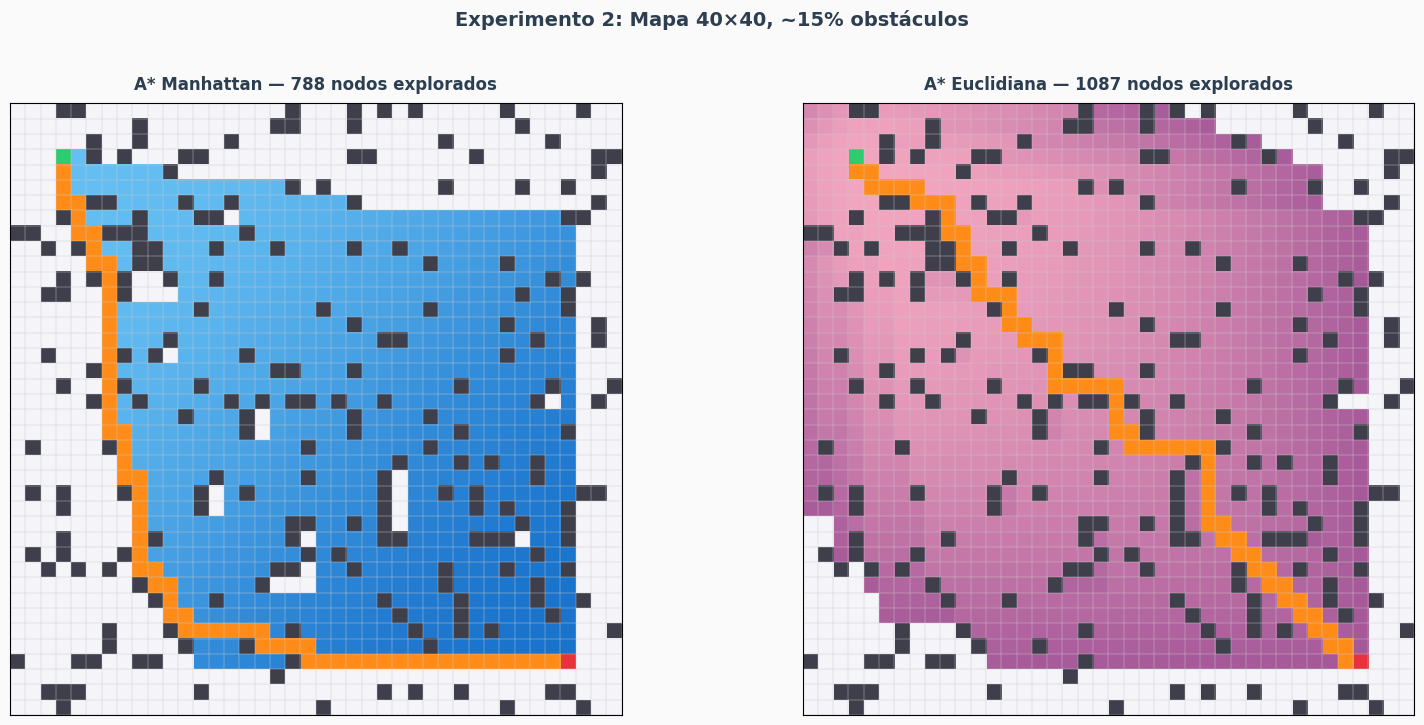


Imagen 2. Experimento 2 — Comparación de nodos explorados con Manhattan y Euclidiana (40×40)


In [5]:
inicio2 = (3, 3)
fin2 = (36, 36)
mapa2 = generarMapa(40, 40, 0.15, semilla=77, inicio=inicio2, fin=fin2)

resManhattan2 = ejecutarAEstrella(mapa2, inicio2, fin2, heuristicaManhattan, 'A* Manhattan')
resEuclidiana2 = ejecutarAEstrella(mapa2, inicio2, fin2, heuristicaEuclidiana, 'A* Euclidiana')

fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#fafafa')

dibujarMapa(ejes[0], mapa2, resManhattan2, inicio2, fin2, colorManhattan,
            f"A* Manhattan — {resManhattan2['numExplorados']} nodos explorados")
dibujarMapa(ejes[1], mapa2, resEuclidiana2, inicio2, fin2, colorEuclidiana,
            f"A* Euclidiana — {resEuclidiana2['numExplorados']} nodos explorados")

plt.suptitle('Experimento 2: Mapa 40×40, ~15% obstáculos', fontsize=14,
             fontweight='bold', color='#2c3e50')
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('exp2_comparacion.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 2. Experimento 2 — Comparación de nodos explorados con Manhattan y Euclidiana (40×40)")

## 5. Experimento 3: Mapa 35×35 con  aprox 25% de obstáculos

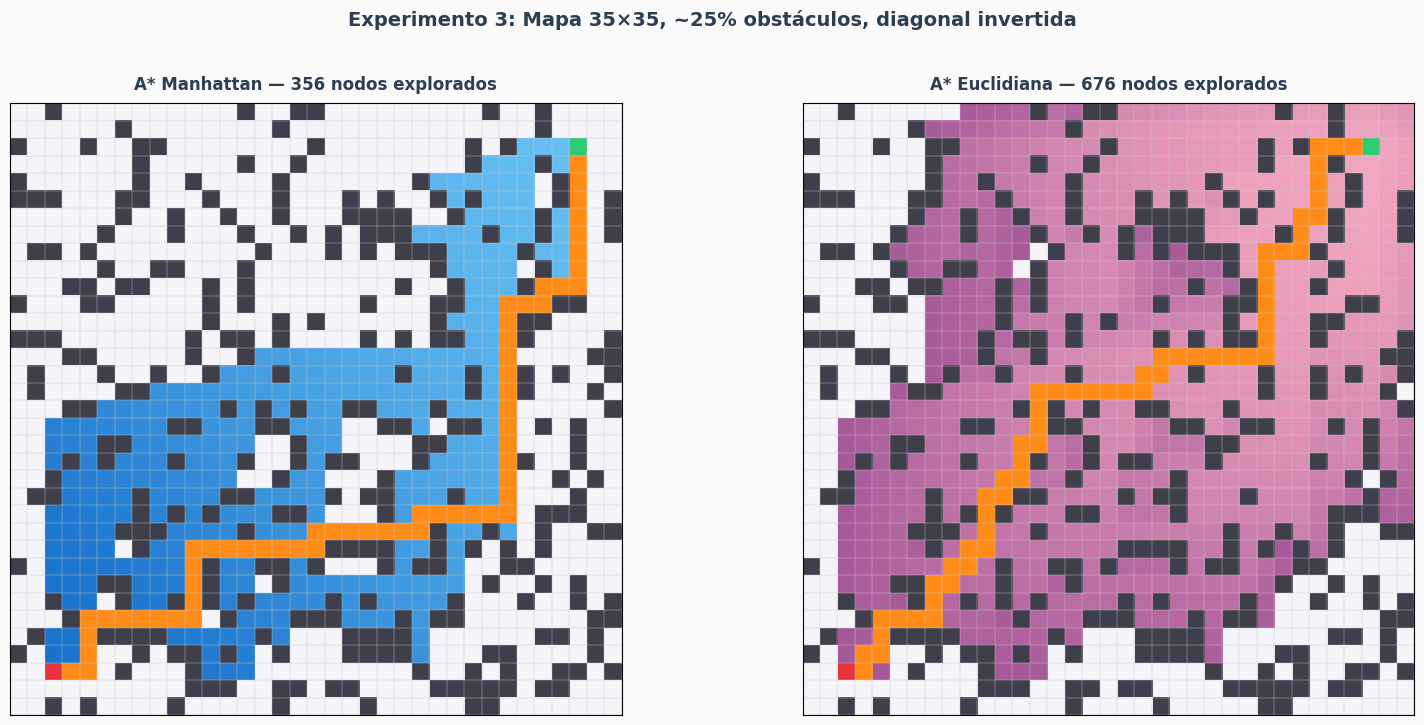


Imagen 3. Experimento 3 — Mapa con inicio y fin en esquinas opuestas invertidas (35×35)


In [6]:
inicio3 = (2, 32)
fin3 = (32, 2)
mapa3 = generarMapa(35, 35, 0.25, semilla=123, inicio=inicio3, fin=fin3)

resManhattan3 = ejecutarAEstrella(mapa3, inicio3, fin3, heuristicaManhattan, 'A* Manhattan')
resEuclidiana3 = ejecutarAEstrella(mapa3, inicio3, fin3, heuristicaEuclidiana, 'A* Euclidiana')

fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#fafafa')

dibujarMapa(ejes[0], mapa3, resManhattan3, inicio3, fin3, colorManhattan,
            f"A* Manhattan — {resManhattan3['numExplorados']} nodos explorados")
dibujarMapa(ejes[1], mapa3, resEuclidiana3, inicio3, fin3, colorEuclidiana,
            f"A* Euclidiana — {resEuclidiana3['numExplorados']} nodos explorados")

plt.suptitle('Experimento 3: Mapa 35×35, ~25% obstáculos, diagonal invertida', fontsize=14,
             fontweight='bold', color='#2c3e50')
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('exp3_comparacion.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 3. Experimento 3 — Mapa con inicio y fin en esquinas opuestas invertidas (35×35)")

## 6. Experimento 4 — Mapa 50×50 con  aprox 10% de obstáculos (grande y abierto)

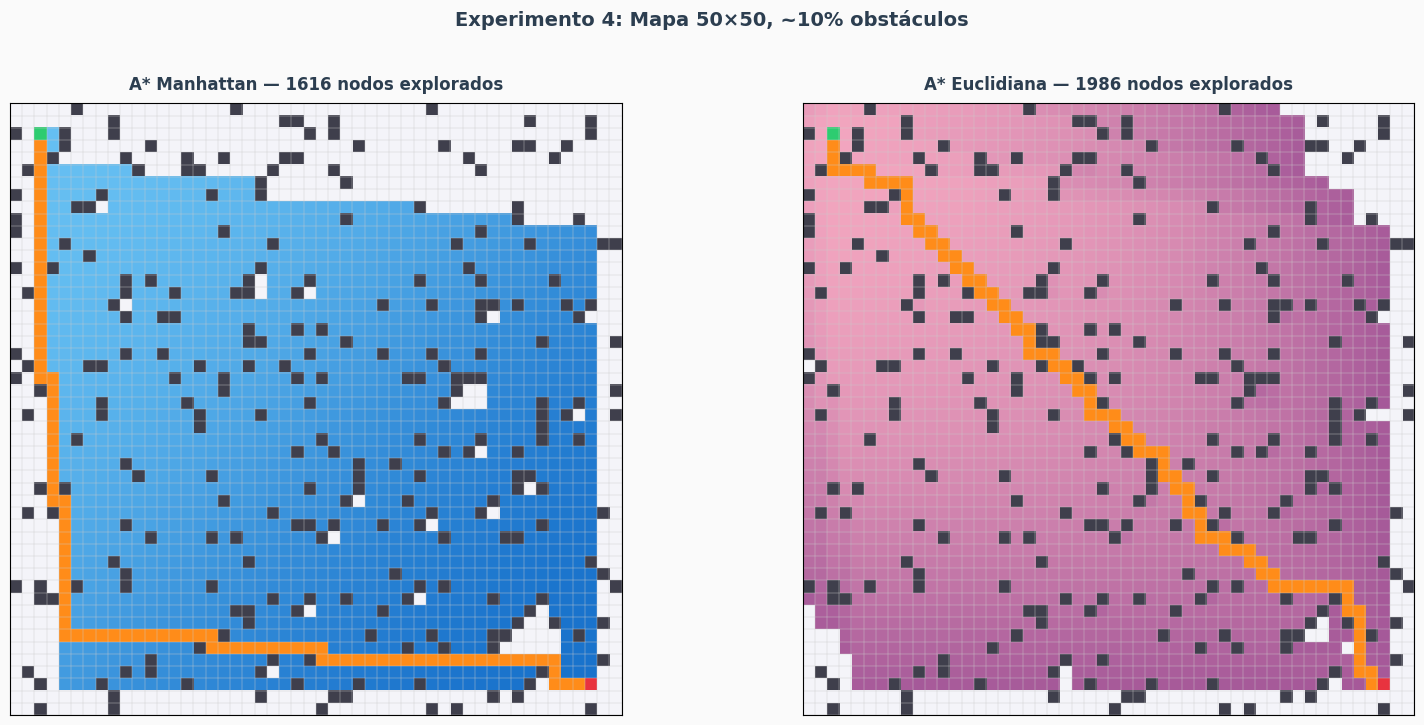


Imagen 4. Experimento 4 — Mapa grande y abierto donde la diferencia se amplifica (50×50)


In [7]:
inicio4 = (2, 2)
fin4 = (47, 47)
mapa4 = generarMapa(50, 50, 0.10, semilla=200, inicio=inicio4, fin=fin4)

resManhattan4 = ejecutarAEstrella(mapa4, inicio4, fin4, heuristicaManhattan, 'A* Manhattan')
resEuclidiana4 = ejecutarAEstrella(mapa4, inicio4, fin4, heuristicaEuclidiana, 'A* Euclidiana')

fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#fafafa')

dibujarMapa(ejes[0], mapa4, resManhattan4, inicio4, fin4, colorManhattan,
            f"A* Manhattan — {resManhattan4['numExplorados']} nodos explorados")
dibujarMapa(ejes[1], mapa4, resEuclidiana4, inicio4, fin4, colorEuclidiana,
            f"A* Euclidiana — {resEuclidiana4['numExplorados']} nodos explorados")

plt.suptitle('Experimento 4: Mapa 50×50, ~10% obstáculos', fontsize=14,
             fontweight='bold', color='#2c3e50')
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig('exp4_comparacion.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 4. Experimento 4 — Mapa grande y abierto donde la diferencia se amplifica (50×50)")

## 7. Tabla comparativa

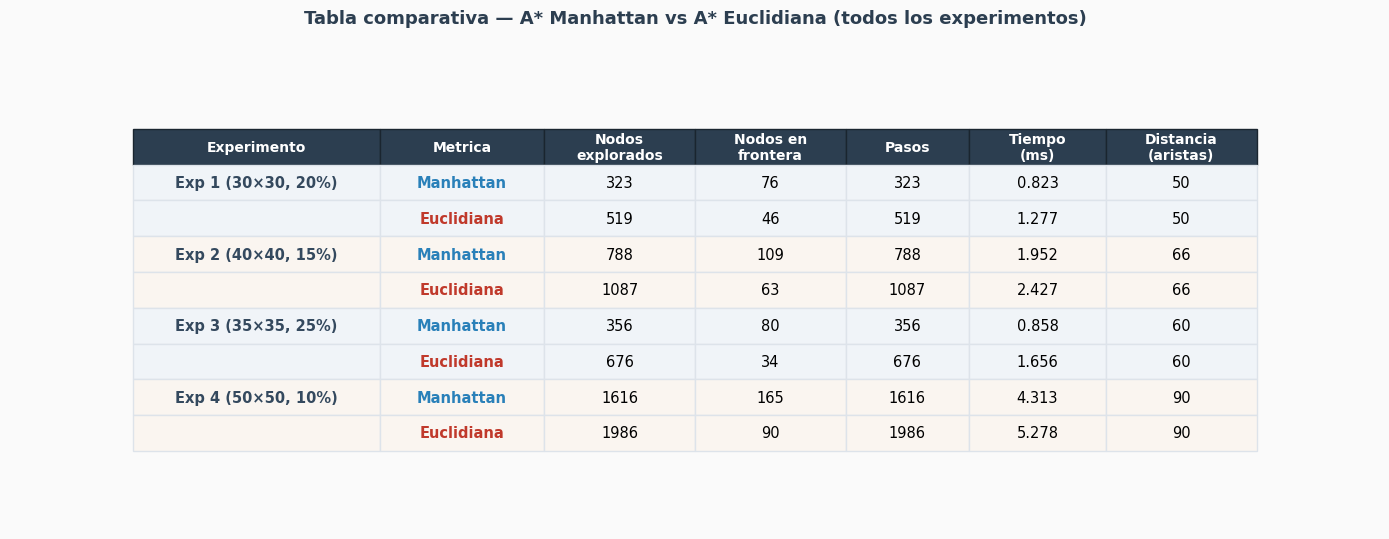


Tabla 1. Resultados de los 4 experimentos


In [8]:
experimentos = [
    ('Exp 1 (30×30, 20%)', resManhattan1, resEuclidiana1),
    ('Exp 2 (40×40, 15%)', resManhattan2, resEuclidiana2),
    ('Exp 3 (35×35, 25%)', resManhattan3, resEuclidiana3),
    ('Exp 4 (50×50, 10%)', resManhattan4, resEuclidiana4),
]

encabezados = ['Experimento', 'Metrica',
               'Nodos\nexplorados', 'Nodos en\nfrontera',
               'Pasos', 'Tiempo\n(ms)', 'Distancia\n(aristas)']

filasTabla = []
for nombre, resM, resE in experimentos:
    filasTabla.append([
        nombre, 'Manhattan',
        str(resM['numExplorados']), str(resM['numFrontera']),
        str(resM['pasos']), f"{resM['tiempo']*1000:.3f}", str(resM['distancia'])
    ])
    filasTabla.append([
        '', 'Euclidiana',
        str(resE['numExplorados']), str(resE['numFrontera']),
        str(resE['pasos']), f"{resE['tiempo']*1000:.3f}", str(resE['distancia'])
    ])

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor('#fafafa')
ax.axis('off')

tabla = ax.table(
    cellText=[encabezados] + filasTabla,
    cellLoc='center',
    loc='center',
    colWidths=[0.18, 0.12, 0.11, 0.11, 0.09, 0.10, 0.11]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10.5)
tabla.scale(1, 1.9)

for j in range(7):
    celda = tabla[0, j]
    celda.set_facecolor('#2c3e50')
    celda.set_text_props(color='white', fontweight='bold', fontsize=10)
    celda.set_edgecolor('#1a252f')

coloresExp = ['#e8f4f8', '#fde8ee']
for i in range(len(filasTabla)):
    indiceFila = i + 1
    indiceExp = i // 2
    esEuclidiana = i % 2 == 1
    colorFondo = '#f0f4f8' if indiceExp % 2 == 0 else '#faf5f0'
    for j in range(7):
        celda = tabla[indiceFila, j]
        celda.set_facecolor(colorFondo)
        celda.set_edgecolor('#dde3ea')
        if j <= 1:
            celda.set_text_props(fontweight='bold', color='#34495e')
        if j == 1:
            color = '#2980b9' if not esEuclidiana else '#c0392b'
            celda.set_text_props(fontweight='bold', color=color)

plt.title('Tabla comparativa — A* Manhattan vs A* Euclidiana (todos los experimentos)',
          fontsize=13, fontweight='bold', color='#2c3e50', pad=20)
plt.tight_layout()
plt.savefig('tabla_comparativa_metricas.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nTabla 1. Resultados de los 4 experimentos")

## 8. Graph de barras agrupadas - Nodos explorados por experimento

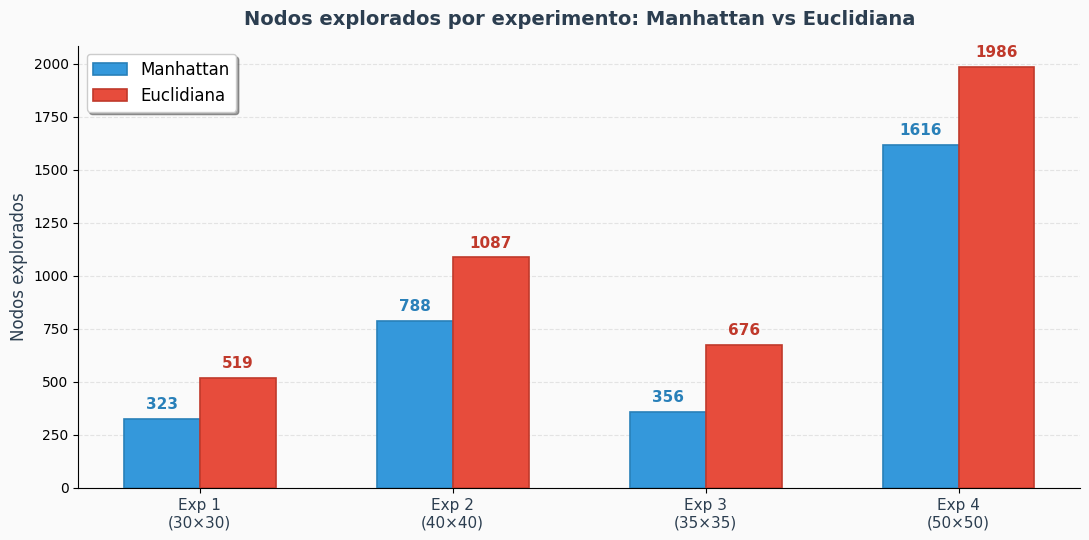


Imagen 5. Nodos explorados en cada experimento


In [9]:
nombresExp = ['Exp 1\n(30×30)', 'Exp 2\n(40×40)', 'Exp 3\n(35×35)', 'Exp 4\n(50×50)']
exploradosManhattan = [resManhattan1['numExplorados'], resManhattan2['numExplorados'],
                       resManhattan3['numExplorados'], resManhattan4['numExplorados']]
exploradosEuclidiana = [resEuclidiana1['numExplorados'], resEuclidiana2['numExplorados'],
                        resEuclidiana3['numExplorados'], resEuclidiana4['numExplorados']]

x = np.arange(len(nombresExp))
ancho = 0.30

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

barrasM = ax.bar(x - ancho/2, exploradosManhattan, ancho, label='Manhattan',
                  color='#3498db', edgecolor='#2980b9', linewidth=1.2, zorder=3)
barrasE = ax.bar(x + ancho/2, exploradosEuclidiana, ancho, label='Euclidiana',
                  color='#e74c3c', edgecolor='#c0392b', linewidth=1.2, zorder=3)

for barra in barrasM:
    alto = barra.get_height()
    ax.annotate(f'{int(alto)}', xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#2980b9')

for barra in barrasE:
    alto = barra.get_height()
    ax.annotate(f'{int(alto)}', xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(nombresExp, fontsize=11, color='#2c3e50')
ax.set_ylabel('Nodos explorados', fontsize=12, color='#2c3e50')
ax.set_title('Nodos explorados por experimento: Manhattan vs Euclidiana',
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, edgecolor='#cccccc')
ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('barras_nodos_explorados.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 5. Nodos explorados en cada experimento")

## 9. Gráfico de barras - Distancias de los caminos encontrados

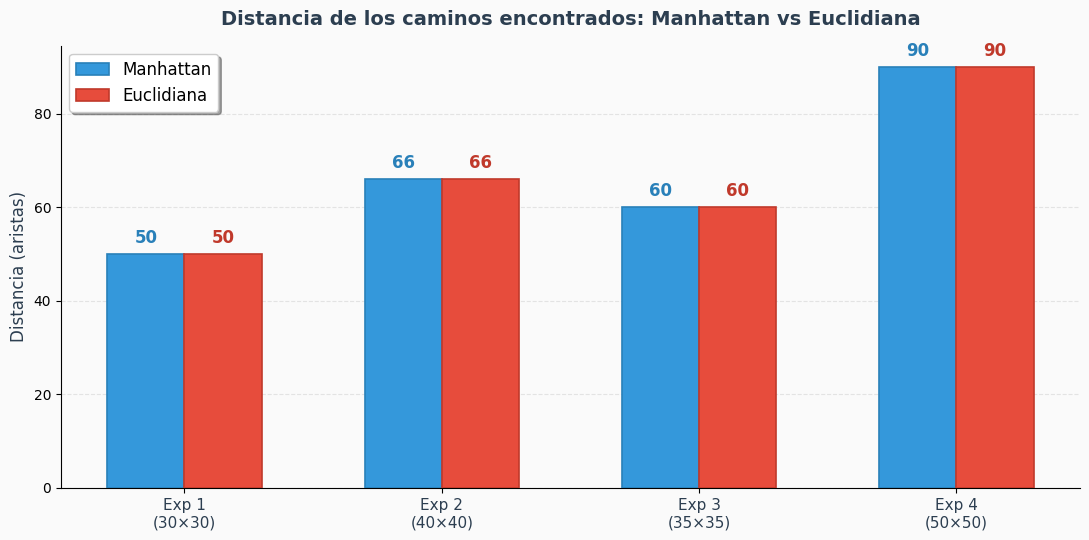


Imagen 6. Distancia de los caminos encontrados en cada experimento


In [10]:
distanciasManhattan = [resManhattan1['distancia'], resManhattan2['distancia'],
                       resManhattan3['distancia'], resManhattan4['distancia']]
distanciasEuclidiana = [resEuclidiana1['distancia'], resEuclidiana2['distancia'],
                        resEuclidiana3['distancia'], resEuclidiana4['distancia']]

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

barrasM = ax.bar(x - ancho/2, distanciasManhattan, ancho, label='Manhattan',
                  color='#3498db', edgecolor='#2980b9', linewidth=1.2, zorder=3)
barrasE = ax.bar(x + ancho/2, distanciasEuclidiana, ancho, label='Euclidiana',
                  color='#e74c3c', edgecolor='#c0392b', linewidth=1.2, zorder=3)

for barra in barrasM:
    alto = barra.get_height()
    ax.annotate(f'{int(alto)}', xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='#2980b9')

for barra in barrasE:
    alto = barra.get_height()
    ax.annotate(f'{int(alto)}', xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='#c0392b')

ax.set_xticks(x)
ax.set_xticklabels(nombresExp, fontsize=11, color='#2c3e50')
ax.set_ylabel('Distancia (aristas)', fontsize=12, color='#2c3e50')
ax.set_title('Distancia de los caminos encontrados: Manhattan vs Euclidiana',
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, edgecolor='#cccccc')
ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('barras_distancias.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 6. Distancia de los caminos encontrados en cada experimento")

## 10. Pregunta

### ¿Cuál métrica produce los caminos más cortos, Manhattan o Euclidiana?

Las 2 producen caminos igual de cortos. ¿Por qué? Porque son heuristicas admisibles. En pocas palabras, estas no sobreestiman el costo real, así que A* siempre encuentra el camino óptimo. El cambio/diferencia cae en la eficiencia porque Manhattan explora menos nodos. En movimiento en 4 direcciones, coincide con el costo ideal sin obstáculos, por lo que guía mejor la search. Ahora yendo con la Euclidiana, esta explora más nodos

In [12]:
#tabla final
print("Verificación de distancias encontradas:")
print(f"{'Experimento':<25} {'Manhattan':>12} {'Euclidiana':>12} {'¿Iguales?':>12}")
print("-" * 63)
for nombre, resM, resE in experimentos:
    iguales = 'YES' if resM['distancia'] == resE['distancia'] else 'NAY'
    print(f"{nombre:<25} {resM['distancia']:>12} {resE['distancia']:>12} {iguales:>12}")

print("\n→ Ambas métricas encuentran caminos de la misma longitud óptima en todos los experimentos.")
print("→ La diferencia está en la eficiencia: Manhattan explora menos nodos.")

print("\nNodos extra explorados por Euclidiana vs Manhattan:")
for nombre, resM, resE in experimentos:
    extra = resE['numExplorados'] - resM['numExplorados']
    porcentaje = (extra / resM['numExplorados']) * 100 if resM['numExplorados'] > 0 else 0
    print(f"  {nombre}: +{extra} nodos (+{porcentaje:.1f}%)")

Verificación de distancias encontradas:
Experimento                  Manhattan   Euclidiana    ¿Iguales?
---------------------------------------------------------------
Exp 1 (30×30, 20%)                  50           50          YES
Exp 2 (40×40, 15%)                  66           66          YES
Exp 3 (35×35, 25%)                  60           60          YES
Exp 4 (50×50, 10%)                  90           90          YES

→ Ambas métricas encuentran caminos de la misma longitud óptima en todos los experimentos.
→ La diferencia está en la eficiencia: Manhattan explora menos nodos.

Nodos extra explorados por Euclidiana vs Manhattan:
  Exp 1 (30×30, 20%): +196 nodos (+60.7%)
  Exp 2 (40×40, 15%): +299 nodos (+37.9%)
  Exp 3 (35×35, 25%): +320 nodos (+89.9%)
  Exp 4 (50×50, 10%): +370 nodos (+22.9%)


## 11. Resumen

| Aspecto | Manhattan | Euclidiana |
|---------|-----------|------------|
| Camino óptimo | Sí | Sí |
| Distancia del camino | Igual | Igual |
| Nodos explorados | Menos | Más |
| Precisión de la estimación | Más ajustada (en cuadrícula 4-dir) | Subestima más |
| Mejor para cuadrícula 4-dir | Sí | No tanto |
| Mejor para movimiento diagonal | No tanto | Sí |